In [71]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

In [72]:
target_crs = "EPSG:4326"

eez = gpd.read_file("./resources/Marine_Regions/World_EEZ_v12/eez_v12.shp")
eez = eez.to_crs(target_crs)

eez_fk = eez[eez["GEONAME"].str.contains("Falkland", case=False, na=False)]
eez_arg = eez[eez["GEONAME"].str.contains("Argentin", case=False, na=False)]

In [73]:
target_res = 0.1
temp_ds = xr.open_dataset("./data/processed/dynamic/to_surface.nc")
effort = xr.open_dataset(f"./data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24



da = temp_ds["to"]

da_filled = da.interpolate_na(
    dim="lon",
    method="nearest"
).interpolate_na(
    dim="lat",
    method="nearest"
)

temp_ds["to"] = da_filled


depth_ds = xr.open_dataset("./data/processed/static/depth.nc")

In [74]:
ugo_ds = xr.open_dataset("./data/processed/dynamic/ugo_surface.nc")
vgo_ds = xr.open_dataset("./data/processed/dynamic/vgo_surface.nc")

u = ugo_ds["ugo"].mean(dim="time")
v = vgo_ds["vgo"].mean(dim="time")

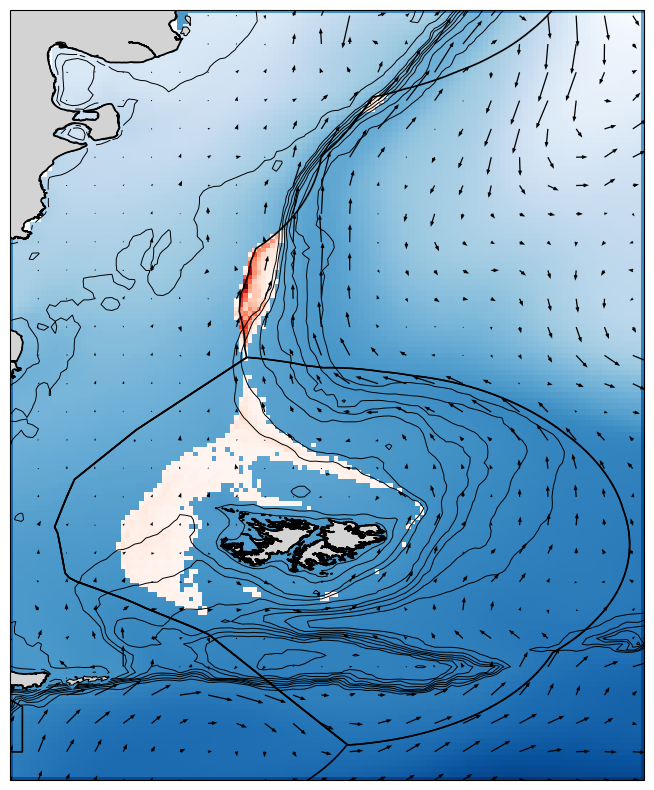

In [79]:
da = temp_ds["to"].mean(dim="time")
da1 = effort.sum(dim="time")
da1 = da1.where(da1 >= 24)
da_depth = depth_ds["depth"]

lon_min = float(da.lon.min())
lon_max = float(da.lon.max())
lat_min = float(da.lat.min())
lat_max = float(da.lat.max())

fig, ax = plt.subplots(
    figsize=(20, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)




da_depth.plot.contour(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=[50, 100, 200, 300, 500, 700, 900, 1200, 1600],
    colors="black",
    linewidths=0.7
)

da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    add_colorbar=False,
)

da1.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    add_colorbar=False,
)

step = 5

lon2d, lat2d = np.meshgrid(da.lon.values, da.lat.values)

q = ax.quiver(
    lon2d[::step, ::step],
    lat2d[::step, ::step],
    u.values[::step, ::step],
    v.values[::step, ::step],
    transform=ccrs.PlateCarree(),
    scale=10,   # adjust arrow size
    width=0.002,
    headwidth=3,
    headlength=4,
    zorder=4
)

ax.add_geometries(
    eez_fk.geometry,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    zorder=6,
    label="Falkland EEZ"
)

ax.add_geometries(
    eez_arg.geometry,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=1.2,
    zorder=6,
    label="Argentina EEZ"
)


ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

plt.show()